# 04 - Generación de predicciones para producción

Este notebook genera los dos ficheros finales de entrega:

- `cs_produccion1.csv`: escenario `FP=1`, `FN=1`.
- `cs_produccion2.csv`: escenario `FP=1`, `FN=10`.

Se cargan:

1. Datos de producción preprocesados.
2. Scaler final.
3. Modelo seleccionado por escenario.
4. Threshold correspondiente.

Los CSV finales mantienen la misma estructura que `cs_produccion.csv`, pero con `SeriousDlqin2yrs` relleno con la predicción binaria.

También se genera un fichero adicional de auditoría con probabilidades/scores y modelo usado, pero los dos ficheros principales son los entregables.

In [1]:
# ==============================
# Imports
# ==============================

from __future__ import annotations

import json
import warnings
from pathlib import Path
from typing import Tuple

import joblib

# Necesario para poder reconstruir ScaledKNNImputer al cargar
# preprocessing_objects.joblib (ver preprocessing_utils.py).
from preprocessing_utils import ScaledKNNImputer  # noqa: F401
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

OUTPUT_DIR = Path("outputs")
OBJECTS_DIR = OUTPUT_DIR / "objects"
MODELS_DIR = OUTPUT_DIR / "models"
PRED_DIR = OUTPUT_DIR / "predictions"
PRED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

Device: cpu


## 1. Carga de producción y objetos entrenados

Este notebook requiere haber ejecutado antes los notebooks 01 y 02.

In [2]:
required_files = [
    OUTPUT_DIR / "preprocessed_prod.csv",
    OBJECTS_DIR / "preprocessing_objects.joblib",
    OBJECTS_DIR / "final_model_scaler.joblib",
    MODELS_DIR / "model_metadata.joblib",
]

for path in required_files:
    if not path.exists():
        raise FileNotFoundError(f"Falta {path}. Ejecuta primero los notebooks 01 y 02.")

prod_df = pd.read_csv(OUTPUT_DIR / "preprocessed_prod.csv")
preprocessing_objects = joblib.load(OBJECTS_DIR / "preprocessing_objects.joblib")
scaler = joblib.load(OBJECTS_DIR / "final_model_scaler.joblib")
model_metadata = joblib.load(MODELS_DIR / "model_metadata.joblib")

TARGET = preprocessing_objects["target"]
FEATURES = preprocessing_objects["final_features"]

print("Producción preprocesada:", prod_df.shape)
print("Features:", len(FEATURES))
print("Modelos seleccionados:")
print(json.dumps(model_metadata["selected_models"], indent=2))

Producción preprocesada: (45000, 26)
Features: 16
Modelos seleccionados:
{
  "cost_1_1": {
    "model_family": "MLP",
    "model_file": "final_mlp.pt",
    "threshold": 0.9226868686868686
  },
  "cost_1_10": {
    "model_family": "MLP",
    "model_file": "final_mlp.pt",
    "threshold": 0.5554343434343434
  }
}


In [3]:
# Opcional: cargamos el fichero original de producción para mantener exactamente sus columnas.
def find_file(filename: str) -> Path:
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd() / filename,
        Path.cwd().parent / "data" / filename,
        Path.cwd().parent / filename,
        Path("/mnt/data") / filename,
    ]
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(filename)

original_prod_path = find_file("cs_produccion.csv")
original_prod = pd.read_csv(original_prod_path)

print("Producción original:", original_prod.shape)
original_prod.head()

# Comprobación de blindaje: las predicciones se asignan a original_prod POR
# POSICIÓN (fila i de prod_df -> fila i de original_prod). Esto solo es
# correcto si los dos ficheros tienen el mismo número de filas Y el mismo
# orden. El notebook 01 nunca elimina duplicados ni reordena producción
# (solo lo hace en construcción), así que debería cumplirse siempre -- pero
# lo comprobamos explícitamente para no depender de que nadie rompa eso sin
# querer en el futuro.
assert len(original_prod) == len(prod_df), (
    f"Desalineación entre cs_produccion.csv ({len(original_prod)} filas) y "
    f"preprocessed_prod.csv ({len(prod_df)} filas). Las predicciones NO se "
    f"pueden asignar por posición si esto no coincide -- revisa el notebook 01."
)
print("Comprobación de alineación OK: mismo número de filas en producción original y preprocesada.")

Producción original: (45000, 11)
Comprobación de alineación OK: mismo número de filas en producción original y preprocesada.


## 2. Reconstrucción de clases PyTorch

Para cargar un modelo guardado con `state_dict`, necesitamos definir la misma arquitectura que en el entrenamiento.

In [4]:
class CreditMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(128, 64, 32), dropout: float = 0.25):
        super().__init__()
        h1, h2, h3 = hidden_dims
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h2, h3),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(h3, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


class ContextualBanditPolicy(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(128, 64), dropout: float = 0.20):
        super().__init__()
        h1, h2 = hidden_dims
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.BatchNorm1d(h1),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.BatchNorm1d(h2),
            nn.Dropout(dropout),
            nn.Linear(h2, 2),
        )

    def forward(self, x):
        return self.net(x)


# "ContextualBanditPolicy_IPS" (bandit de feedback parcial, notebook 02) usa
# la misma arquitectura que "ContextualBanditPolicy" (bandit de información
# completa) -- lo único que cambia entre ellos es cómo se entrenaron, no la
# red en sí. Por eso comparten clase aquí.
BANDIT_FAMILIES = {"ContextualBanditPolicy", "ContextualBanditPolicy_IPS"}


def load_torch_model(model_path: Path):
    checkpoint = torch.load(model_path, map_location=DEVICE)
    model_type = checkpoint["model_type"]

    if model_type == "MLP":
        model = CreditMLP(
            input_dim=checkpoint["input_dim"],
            hidden_dims=tuple(checkpoint["hidden_dims"]),
            dropout=checkpoint["dropout"],
        )
    elif model_type in BANDIT_FAMILIES:
        model = ContextualBanditPolicy(
            input_dim=checkpoint["input_dim"],
            hidden_dims=tuple(checkpoint["hidden_dims"]),
            dropout=checkpoint["dropout"],
        )
    else:
        raise ValueError(
            f"Modelo no reconocido: {model_type!r}. "
            f"Tipos soportados: 'MLP', {sorted(BANDIT_FAMILIES)}."
        )

    model.load_state_dict(checkpoint["state_dict"])
    model.to(DEVICE)
    model.eval()
    return model, checkpoint


def predict_model_score(model, model_family: str, X_scaled_array: np.ndarray, batch_size: int = 4096) -> np.ndarray:
    scores = []
    with torch.no_grad():
        for start in range(0, len(X_scaled_array), batch_size):
            xb = torch.tensor(X_scaled_array[start:start + batch_size], dtype=torch.float32, device=DEVICE)
            if model_family == "MLP":
                score = torch.sigmoid(model(xb)).cpu().numpy()
            elif model_family in BANDIT_FAMILIES:
                score = F.softmax(model(xb), dim=1)[:, 1].cpu().numpy()
            else:
                raise ValueError(
                    f"model_family no reconocida: {model_family!r}. "
                    f"Soportadas: 'MLP', {sorted(BANDIT_FAMILIES)}."
                )
            scores.append(score)
    return np.concatenate(scores)


def predict_for_scenario(scenario: str) -> Tuple[np.ndarray, np.ndarray, dict]:
    selected = model_metadata["selected_models"][scenario]
    model_path = MODELS_DIR / selected["model_file"]
    model, checkpoint = load_torch_model(model_path)

    X_prod = prod_df[FEATURES].astype(float)
    X_prod_scaled = scaler.transform(X_prod)

    score = predict_model_score(model, selected["model_family"], X_prod_scaled)
    pred = (score >= selected["threshold"]).astype(int)
    return score, pred, selected


## 3. Generación de predicciones

Generamos un CSV por escenario.

- En `cost_1_1`, el threshold busca minimizar errores con mismo coste.
- En `cost_1_10`, el threshold/política penaliza mucho más los falsos negativos.

Por tanto, normalmente `cs_produccion2.csv` debería tener más predicciones `1` que `cs_produccion1.csv`, porque el modelo es más conservador.

In [5]:
prediction_details = []

for scenario, params in model_metadata["scenarios"].items():
    print("\nGenerando predicciones para:", scenario)
    score, pred, selected = predict_for_scenario(scenario)

    # Fichero de entrega: misma estructura que producción original, con target relleno.
    output = original_prod.copy()
    output[TARGET] = pred.astype(int)

    output_file = PRED_DIR / params["output_file"]
    output.to_csv(output_file, index=False)

    # Fichero de auditoría con detalle.
    detail = pd.DataFrame({
        "row_id": np.arange(len(pred)),
        "scenario": scenario,
        "model_family": selected["model_family"],
        "model_file": selected["model_file"],
        "threshold": selected["threshold"],
        "score_class_1": score,
        "prediction": pred.astype(int),
    })
    prediction_details.append(detail)

    print("Guardado:", output_file)
    print("Distribución predicciones:")
    display(output[TARGET].value_counts(normalize=False).rename_axis("prediction").reset_index(name="n"))
    display(output[TARGET].value_counts(normalize=True).rename_axis("prediction").reset_index(name="pct"))

prediction_details_df = pd.concat(prediction_details, ignore_index=True)
prediction_details_df.to_csv(PRED_DIR / "production_prediction_details.csv", index=False)

print("Detalle guardado en:", PRED_DIR / "production_prediction_details.csv")


Generando predicciones para: cost_1_1


Guardado: outputs/predictions/cs_produccion1.csv
Distribución predicciones:


,prediction,n
0,0,43741
1,1,1259


,prediction,pct
0,0,0.9720
1,1,0.0280



Generando predicciones para: cost_1_10


Guardado: outputs/predictions/cs_produccion2.csv
Distribución predicciones:


,prediction,n
0,0,36239
1,1,8761


,prediction,pct
0,0,0.8053
1,1,0.1947


Detalle guardado en: outputs/predictions/production_prediction_details.csv


In [6]:
# Comprobaciones de formato.
for scenario, params in model_metadata["scenarios"].items():
    path = PRED_DIR / params["output_file"]
    df_check = pd.read_csv(path)

    assert df_check.shape[0] == original_prod.shape[0], "El número de filas debe coincidir con producción."
    assert list(df_check.columns) == list(original_prod.columns), "Las columnas deben coincidir con producción original."
    assert df_check[TARGET].isin([0, 1]).all(), "El target predicho debe ser binario 0/1."

    print(path.name, "OK", df_check.shape)

cs_produccion1.csv OK (45000, 11)
cs_produccion2.csv OK (45000, 11)


## 4. Comparación entre escenarios

La comparación siguiente permite verificar que el segundo escenario cambia la política de decisión. Si `FN=10`, se espera que el modelo sea más sensible a detectar la clase 1.

In [7]:
comparison = prediction_details_df.pivot(index="row_id", columns="scenario", values="prediction").reset_index()
scenario_cols = [c for c in comparison.columns if c != "row_id"]

if set(["cost_1_1", "cost_1_10"]).issubset(comparison.columns):
    comparison["changed"] = comparison["cost_1_1"] != comparison["cost_1_10"]
    print("Filas con distinta predicción entre escenarios:", comparison["changed"].sum())
    print("Porcentaje:", 100 * comparison["changed"].mean())

    # Comprobamos explícitamente la hipótesis del enunciado de esta sección:
    # con FN=10, el modelo debería ser más conservador y predecir más 1
    # (denegaciones) que con FP=FN=1. Antes esto solo se podía ver "a ojo"
    # mirando la tabla; ahora queda verificado con un mensaje claro.
    rate_1_1 = comparison["cost_1_1"].mean()
    rate_1_10 = comparison["cost_1_10"].mean()
    print(f"\nTasa de predicción 1 en cost_1_1: {rate_1_1:.4f}")
    print(f"Tasa de predicción 1 en cost_1_10: {rate_1_10:.4f}")

    if rate_1_10 >= rate_1_1:
        print("OK: cost_1_10 predice 1 (deniega) con más frecuencia que cost_1_1, como se esperaba.")
    else:
        print(
            "AVISO: cost_1_10 predice 1 con MENOS frecuencia que cost_1_1. "
            "Esto contradice la hipótesis de la sección 3 -- revisar thresholds/modelos seleccionados."
        )

comparison.head()

Filas con distinta predicción entre escenarios: 7502
Porcentaje: 16.671111111111113

Tasa de predicción 1 en cost_1_1: 0.0280
Tasa de predicción 1 en cost_1_10: 0.1947
OK: cost_1_10 predice 1 (deniega) con más frecuencia que cost_1_1, como se esperaba.


scenario,row_id,cost_1_1,cost_1_10,changed
0,0,1,1,False
1,1,1,1,False
2,2,0,0,False
3,3,0,0,False
4,4,0,0,False


In [8]:
# Resumen de scores por escenario.
score_summary = prediction_details_df.groupby("scenario").agg(
    n=("prediction", "size"),
    predicted_1=("prediction", "sum"),
    predicted_1_rate=("prediction", "mean"),
    score_mean=("score_class_1", "mean"),
    score_p50=("score_class_1", "median"),
    score_p90=("score_class_1", lambda s: s.quantile(0.90)),
    score_p99=("score_class_1", lambda s: s.quantile(0.99)),
).reset_index()

score_summary

,scenario,n,predicted_1,predicted_1_rate,score_mean,score_p50,score_p90,score_p99
0,cost_1_1,45000,1259,0.0280,0.3493,0.2908,0.7590,0.9696
1,cost_1_10,45000,8761,0.1947,0.3493,0.2908,0.7590,0.9696


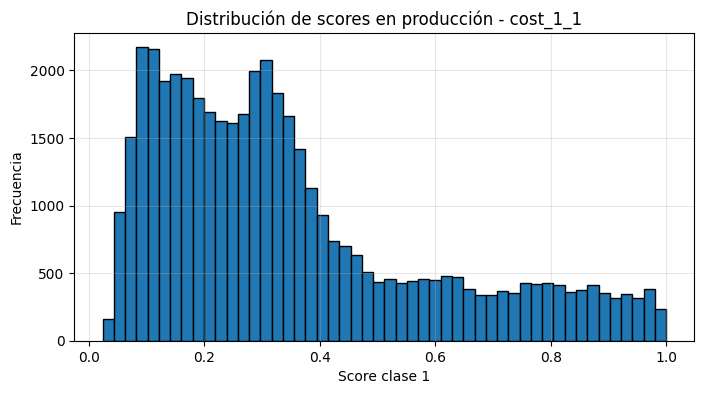

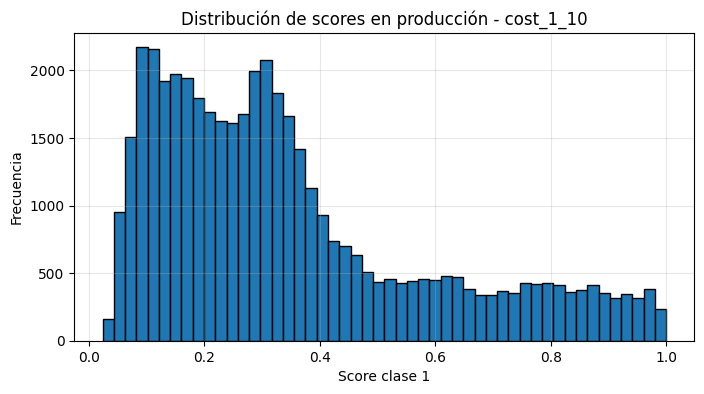

In [9]:
# Histograma de scores por escenario.
for scenario in prediction_details_df["scenario"].unique():
    temp = prediction_details_df[prediction_details_df["scenario"] == scenario]
    plt.figure(figsize=(8, 4))
    plt.hist(temp["score_class_1"], bins=50, edgecolor="black")
    plt.title(f"Distribución de scores en producción - {scenario}")
    plt.xlabel("Score clase 1")
    plt.ylabel("Frecuencia")
    plt.grid(alpha=0.3)
    plt.show()

## 5. Ficheros finales

Los ficheros que hay que entregar están en:

- `outputs/predictions/cs_produccion1.csv`
- `outputs/predictions/cs_produccion2.csv`

El fichero `production_prediction_details.csv` no es obligatorio para la entrega, pero sirve para auditoría interna porque contiene score, threshold y modelo utilizado.